# Project data exploration - looking at relplot and scatter plots
Using a dataset that your group is consider using for the term project, let's do some data exploring of the different features in your dataset and their relationships

Group name: Team Sport Analytics  
Created by Jake Crumley (016879759), Matija Malisic (016608696), Sumit Shrestha (017765020), Carter Alemania (017684108)         
Last updated: 3/22/2026  
Briefly describe your dataset

Import your data. If you want to mount your Google drive you can use `from google.colab import drive` and `drive.mount('/content/drive')`

In [ ]:
#data import
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
team_stats = pd.read_csv('/content/drive/MyDrive/NBA Stats/TeamStatisticsAdvanced.csv')

In [ ]:
team_stats.drop(columns = ['teamId', 'availableFlag', 'gameDateTimeEst', 'win', 'teamName_right'], inplace = True)

In [ ]:
team_stats = team_stats[team_stats['gameType'].isin(['Regular Season', 'Playoffs'])]

In [ ]:
team_stats.head()

,gameId,teamCity,teamName,gameType,astPct,astRatio,astTo,defRating,drebPct,eDefRating,...,orebPct,pace,pacePer40,pie,poss,rebPct,teamAbbreviation,tmTovPct,tsPct,wl
0,22500742,Detroit,Pistons,Regular Season,0.705,23.3,2.38,84.2,0.736,84.7,...,0.225,94.0,78.33,0.708,93,0.516,DET,0.140,0.658,W
1,22500745,Portland,Trail Blazers,Regular Season,0.633,20.9,1.72,110.6,0.735,111.4,...,0.310,104.0,86.67,0.578,104,0.538,POR,0.173,0.680,W
2,22500744,New Orleans,Pelicans,Regular Season,0.674,21.2,1.81,118.6,0.610,119.2,...,0.282,97.0,80.83,0.540,97,0.480,NOP,0.165,0.663,W
3,22500746,LA,Clippers,Regular Season,0.595,16.9,1.38,114.4,0.679,110.3,...,0.225,98.0,81.67,0.537,99,0.484,LAC,0.162,0.656,W
4,22500743,Indiana,Pacers,Regular Season,0.743,20.6,2.89,114.1,0.654,108.7,...,0.152,92.5,77.08,0.513,93,0.418,IND,0.097,0.561,L


In [ ]:
team_stats.columns

Index(['gameId', 'teamCity', 'teamName', 'gameType', 'astPct', 'astRatio',
       'astTo', 'defRating', 'drebPct', 'eDefRating', 'eNetRating',
       'eOffRating', 'ePace', 'efgPct', 'gameDate', 'home', 'matchup', 'min',
       'netRating', 'offRating', 'opponentTeamCity', 'opponentTeamId',
       'opponentTeamName', 'orebPct', 'pace', 'pacePer40', 'pie', 'poss',
       'rebPct', 'teamAbbreviation', 'tmTovPct', 'tsPct', 'wl'],
      dtype='object')

In [ ]:
team_stats.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6472 entries, 0 to 10103
Data columns (total 33 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gameId            6472 non-null   int64  
 1   teamCity          6254 non-null   object 
 2   teamName          6254 non-null   object 
 3   gameType          6472 non-null   object 
 4   astPct            6472 non-null   float64
 5   astRatio          6472 non-null   float64
 6   astTo             6472 non-null   float64
 7   defRating         6472 non-null   float64
 8   drebPct           6016 non-null   float64
 9   eDefRating        6472 non-null   float64
 10  eNetRating        6472 non-null   float64
 11  eOffRating        6472 non-null   float64
 12  ePace             6472 non-null   float64
 13  efgPct            6472 non-null   float64
 14  gameDate          6472 non-null   object 
 15  home              6254 non-null   float64
 16  matchup           6460 non-null   object 
 17 

### Q1: Show the number of missing data in each column of the dataframe

In [ ]:
# Your code here . . .
team_stats.isnull().sum()

,0
gameId,0
teamCity,218
teamName,218
gameType,0
astPct,0
astRatio,0
astTo,0
defRating,0
drebPct,456
eDefRating,0


### Q2: Show the data type for each column of the dataframe

In [ ]:
# Your code here . . .
team_stats.dtypes

,0
gameId,int64
teamCity,object
teamName,object
gameType,object
astPct,float64
astRatio,float64
astTo,float64
defRating,float64
drebPct,float64
eDefRating,float64


### Q3: Create a pair plot to show pairwise relationship in this dataset.
Draw the pairwise polynomial regression lines in a different color than the data points. Use a light color for the data points to deemphasizing the points to make the regression line stand out. Include a meaningful title to the plot.

In [ ]:
%matplotlib inline

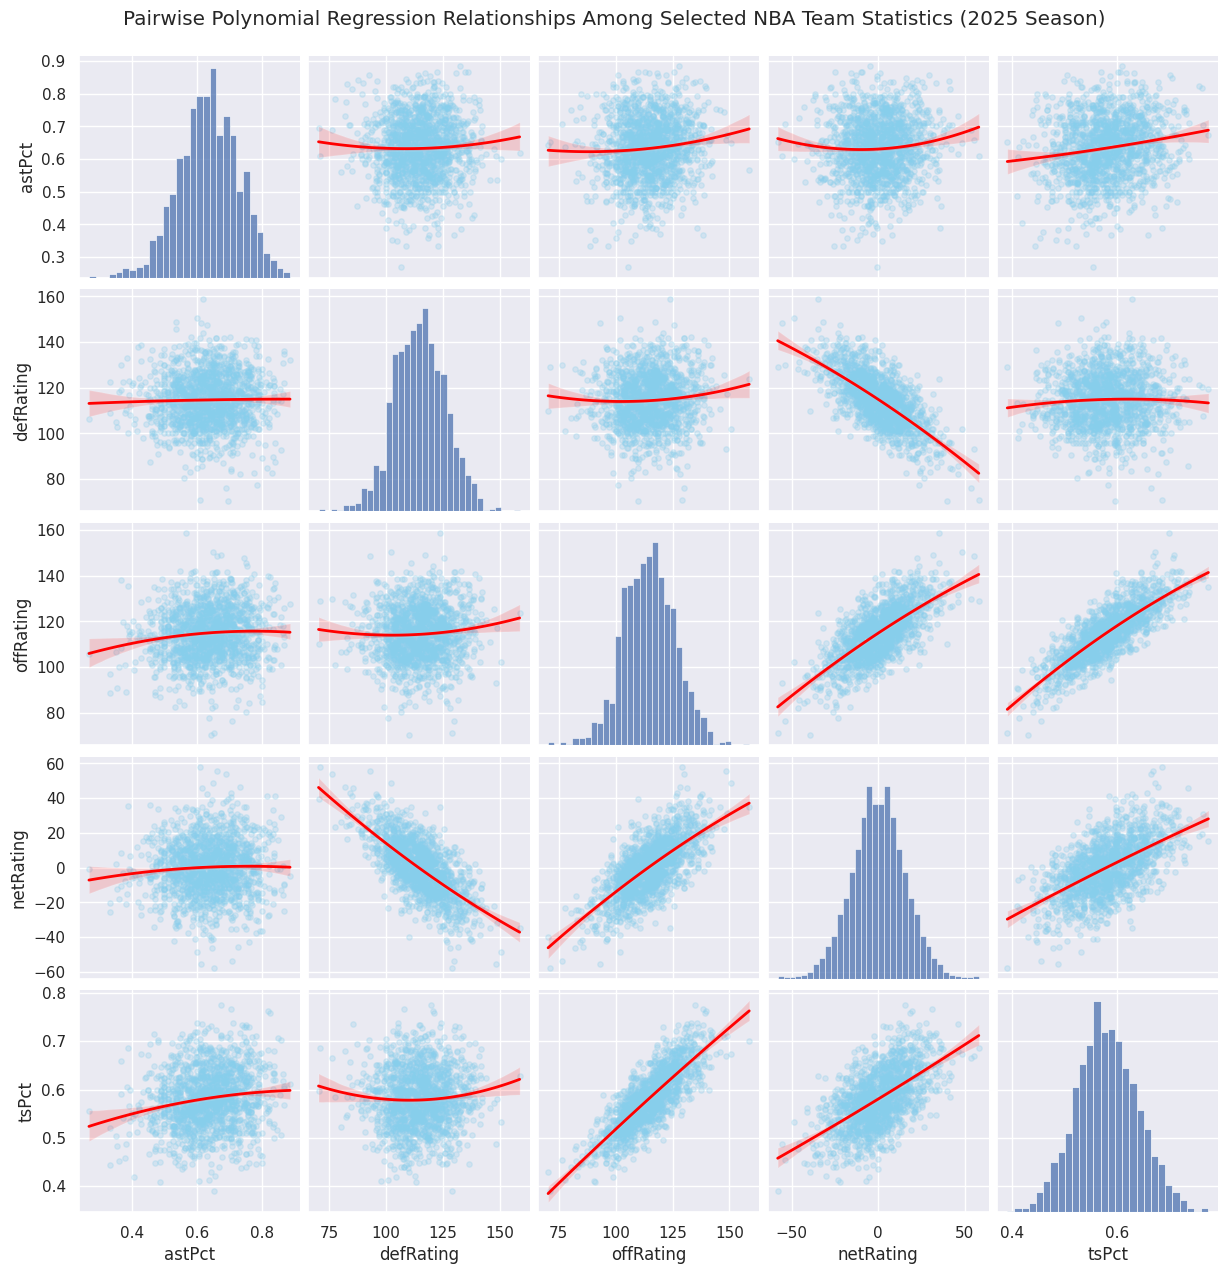

In [ ]:
# Your code here . . .
team_stats['gameDate'] = pd.to_datetime(team_stats['gameDate'])
this_szn = team_stats[team_stats['gameDate'] >= '2025-10-01']
cols = ['astPct', 'defRating', 'offRating', 'netRating', 'tsPct']
p = sns.pairplot(
    this_szn[cols],
    kind='reg',
    plot_kws={
        'order': 2,
        'scatter_kws': {'color': 'skyblue', 'alpha': 0.25, 's': 15},
        'line_kws': {'color': 'red', 'linewidth': 2}
    }
)
p.fig.suptitle('Pairwise Polynomial Regression Relationships Among Selected NBA Team Statistics (2025 Season)', y=1.02)
plt.show()

### Q4: Plot a regression line and confidence interval
Select two of the features from your dataset and create a lmplot that shows the linear regression between them. Filter your data as you see fit. Include a meaningful title for the plot.

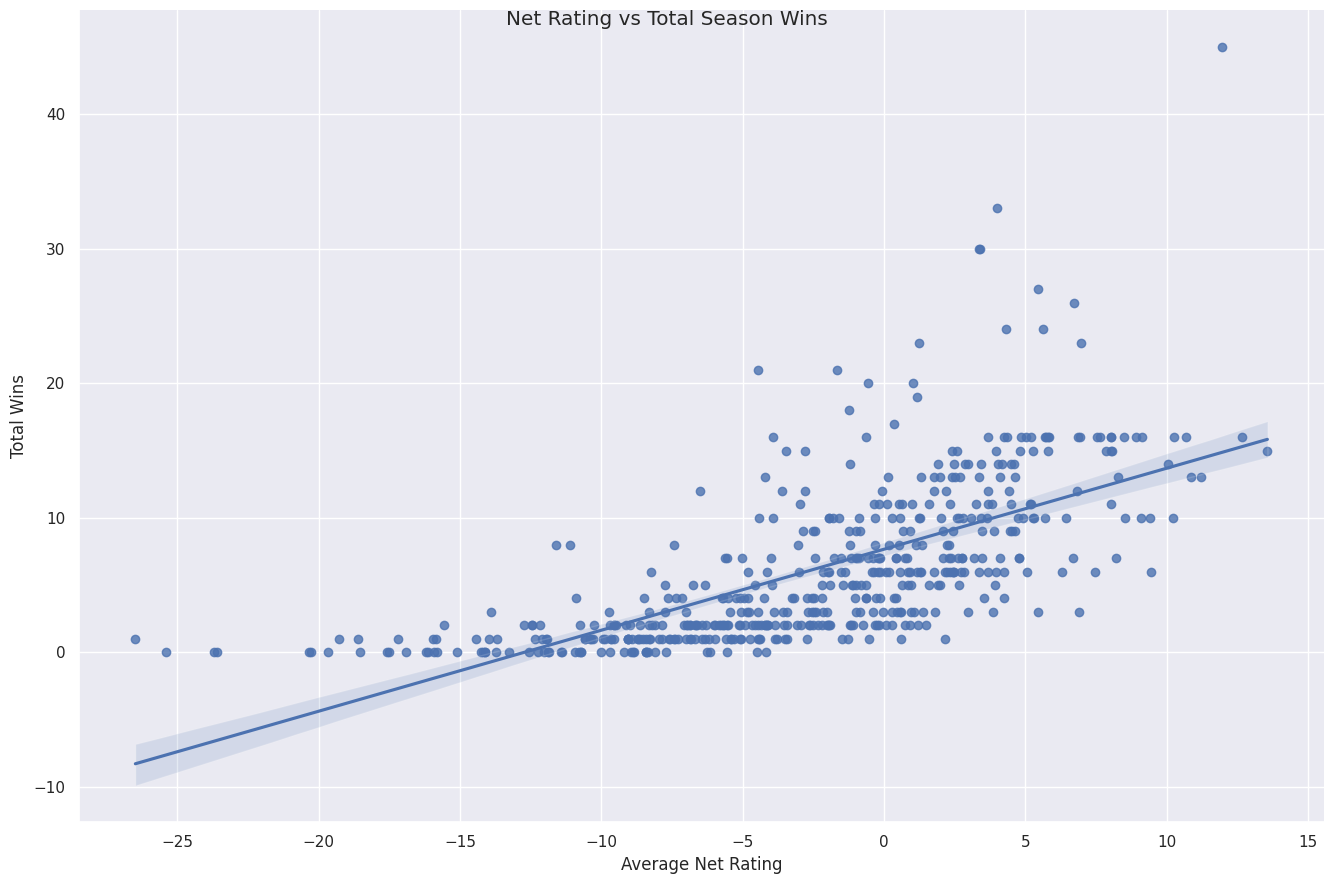

In [ ]:
# Your code here . . .
df = (team_stats
      .assign(
          win_flag=(team_stats['wl'] == 'W').astype(int),
          season=team_stats['gameDate'].dt.year
      )
      .groupby(['teamName', 'season'], as_index=False)
      .agg(Wins=('win_flag', 'sum'),
           netRating=('netRating', 'mean'))
)
g = sns.lmplot(data=df, x='netRating', y='Wins', ci=95, height=9, aspect=1.5)
g.fig.suptitle('Net Rating vs Total Season Wins')
g.set_axis_labels('Average Net Rating', 'Total Wins')
plt.show()

### Q5. Create a relplot that shows multiple features in a single plot.
Select two features from your dataset and plot a scatter plot. Select two additional features you want to highlight in your data points using `hue` and `size`. Include a meaningful title to the plot.

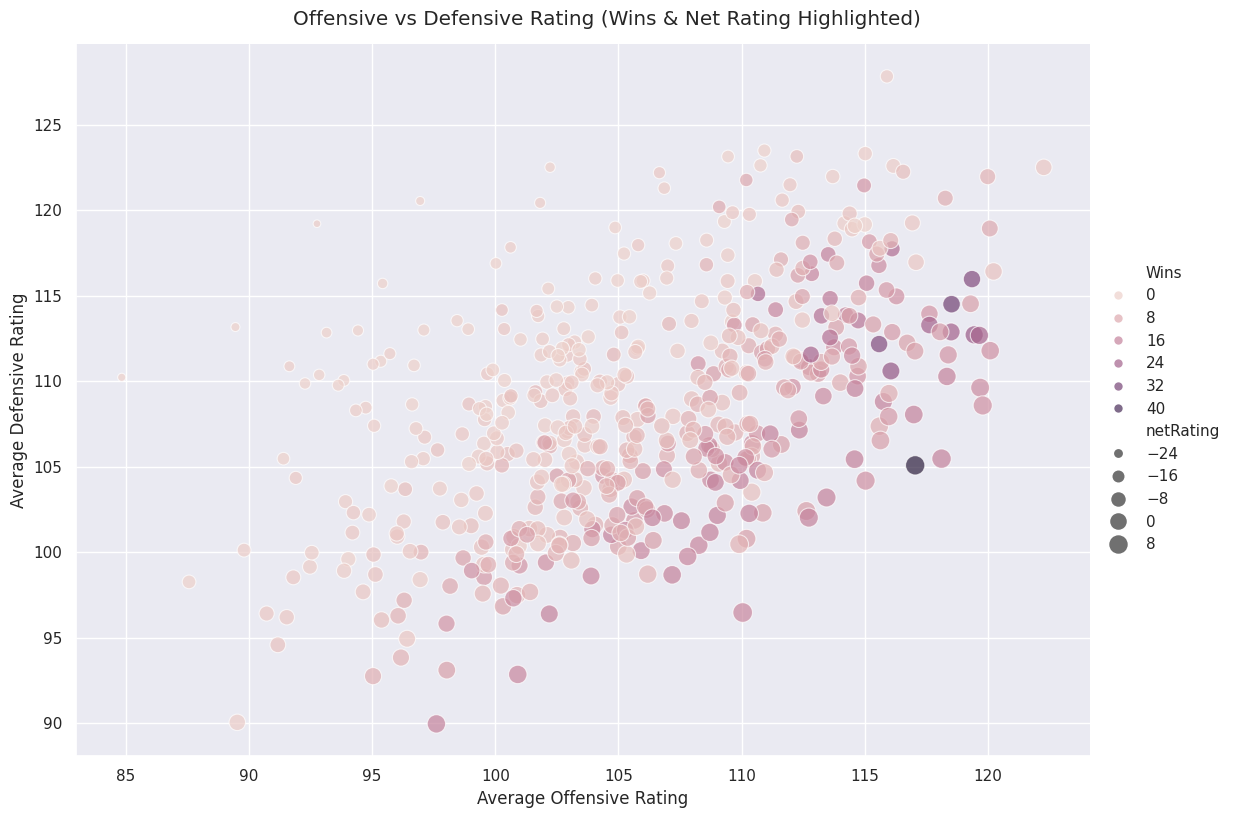

In [ ]:

# Your code here . . .
df = (team_stats
      .assign(
          win_flag=(team_stats['wl'] == 'W').astype(int),
          season=team_stats['gameDate'].dt.year
      )
      .groupby(['teamName', 'season'], as_index=False)
      .agg(Wins=('win_flag', 'sum'),
           offRating=('offRating', 'mean'),
           defRating=('defRating', 'mean'),
           netRating=('netRating', 'mean'))
)
g = sns.relplot(
    data=df,
    x='offRating',
    y='defRating',
    hue='Wins',
    size='netRating',
    sizes=(30, 200),
    alpha=0.7,
    height=8,
    aspect=1.4
)
g.fig.suptitle('Offensive vs Defensive Rating (Wins & Net Rating Highlighted)', y=1.02)
g.set_axis_labels('Average Offensive Rating', 'Average Defensive Rating')
plt.show()

### Q6: Create a plot with small multiples plots
Select two features from your dataset and show the relationship between the features with an additional feature as the single category. Organize the multiple plots to have 3 plots per row. Set the `height` of the plot to 5 and the size the of data point to 20. Include a meaningful title in the plot.

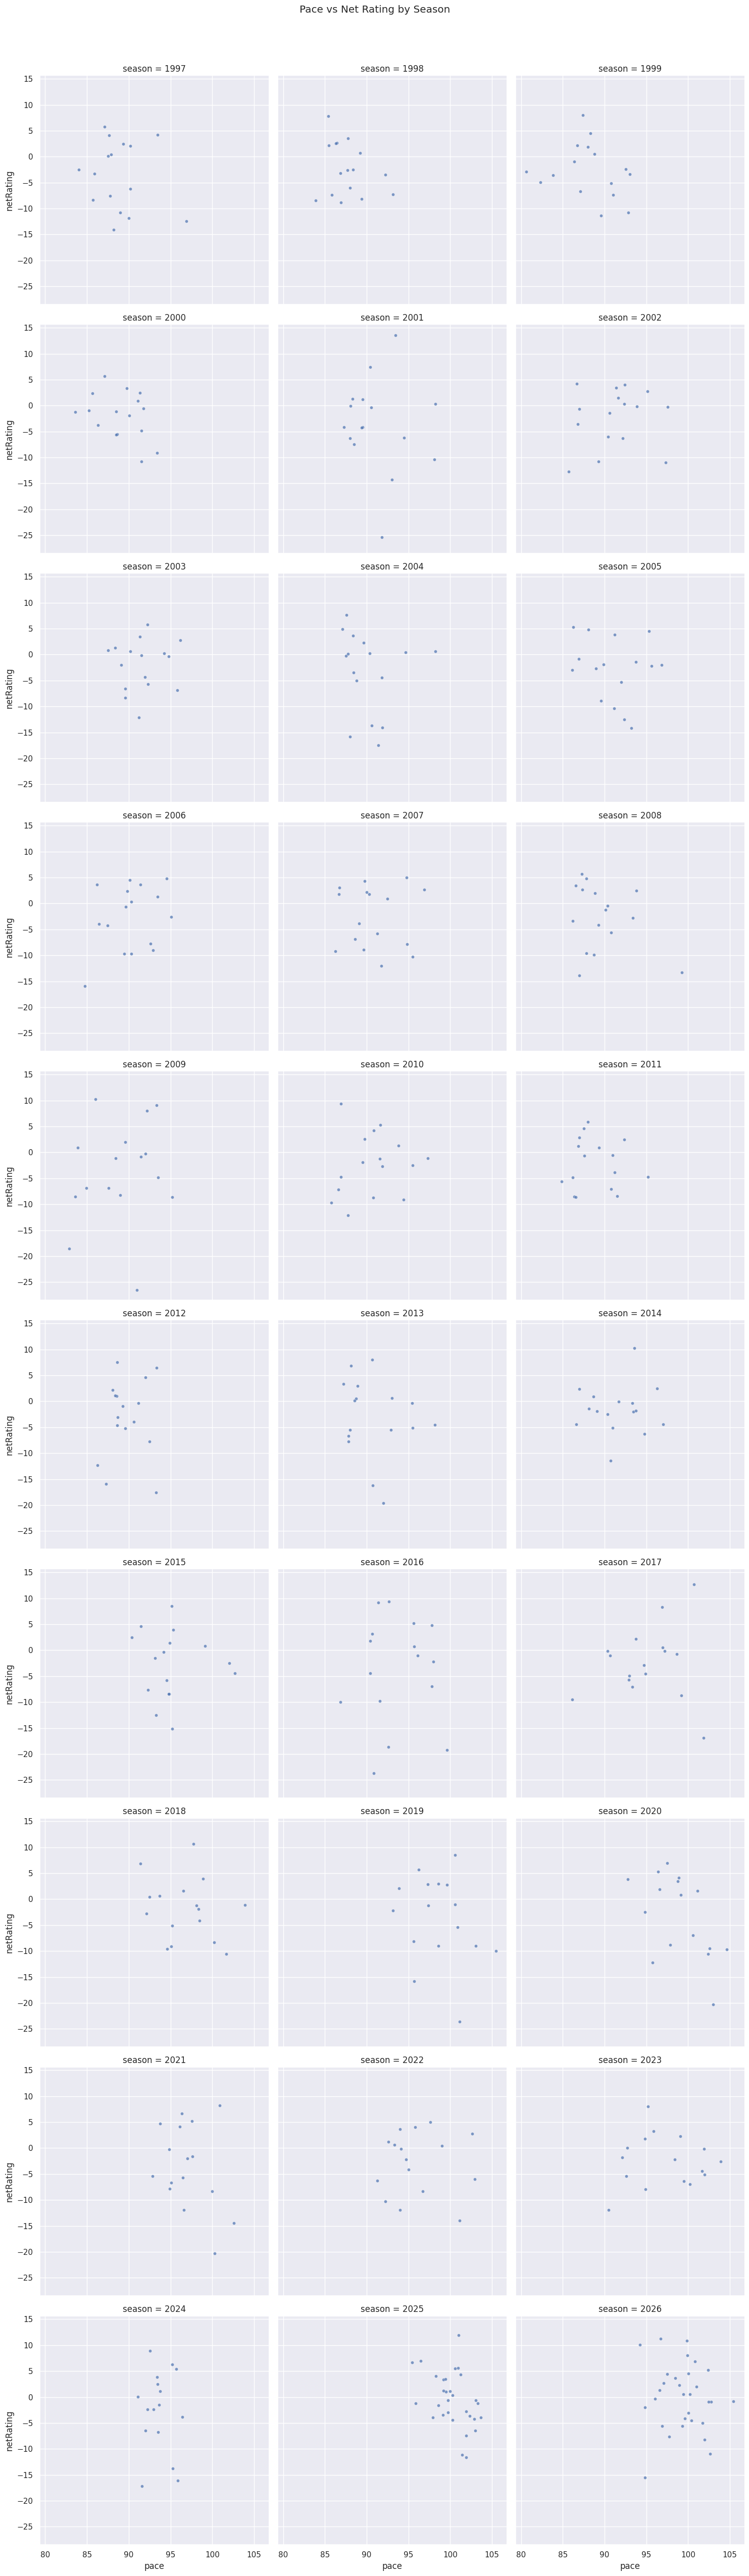

In [ ]:
# Your code here . . .
df = (team_stats
      .assign(
          win_flag=(team_stats['wl'] == 'W').astype(int),
          season=team_stats['gameDate'].dt.year
      )
      .groupby(['teamName', 'season'], as_index=False)
      .agg(pace=('pace', 'mean'),
           netRating=('netRating', 'mean'))
)
sns.relplot(
    data=df,
    x='pace',
    y='netRating',
    col='season',
    col_wrap=3,
    height=5,
    s=20,
    alpha=0.7
)
plt.suptitle('Pace vs Net Rating by Season', y=1.02)
plt.show()